# Analyze OFF Category Frequencies

Overall Goal: Find food categories that are suitable for search autosuggestion. Use most popular categories as input for manual curation.

Hypothesis: Categories with many products are more popular, i.e. more frequently bought and/or more diverse product palette/manufaturers.

https://world.openfoodfacts.org/categories.json&page=10&page_size=10

In [1]:
from IPython.display import Image
from networkx.drawing.nx_agraph import to_agraph
from openfoodfacts.taxonomy import get_taxonomy, Taxonomy, TaxonomyNode
from urllib.request import urlopen, urlretrieve
from urllib.parse import urlencode
from pathlib import Path
import io
import pandas as pd
import networkx as nx
import json
import time

## Download Category Pages

- contains number of products per category

In [2]:
API_URL = "https://world.openfoodfacts.org/categories.json?"

def download_cat_page(page: int):
    params = {"page_size": 1000, "page": page}

    out_file = f"./off_cat_frequencies_page{page}.json"

    # skip download if data has been downloaded before
    if not Path(out_file).exists():
        print(f"LOADING: cat page {page}")
        urlretrieve(API_URL + urlencode(params), out_file)
    else:
        print(f"SKIP: {out_file} already exists")

In [3]:
%%time
for page in range(1,9):
    time.sleep(0.5)
    download_cat_page(page)

SKIP: ./off_cat_frequencies_page1.json already exists
SKIP: ./off_cat_frequencies_page2.json already exists
SKIP: ./off_cat_frequencies_page3.json already exists
SKIP: ./off_cat_frequencies_page4.json already exists
SKIP: ./off_cat_frequencies_page5.json already exists
SKIP: ./off_cat_frequencies_page6.json already exists
SKIP: ./off_cat_frequencies_page7.json already exists
SKIP: ./off_cat_frequencies_page8.json already exists
CPU times: user 137 ms, sys: 4.83 ms, total: 141 ms
Wall time: 4.03 s


## Combine JSON files in DataFrame

In [4]:
def load_cat_as_df(page: int):
    file = f"./off_cat_frequencies_page{page}.json"
    
    # load json file
    with open(file) as f:
        data = json.load(f)

    # create data frame from product information
    return (pd.DataFrame(data['tags'])
              .drop(['url', 'sameAs'], axis=1)
              .set_index('id')
           )

In [5]:
all_dfs = [load_cat_as_df(page) for page in range(1,9)]
cat_df = pd.concat(all_dfs)
# remove duplicates
cat_df = cat_df[~cat_df.index.duplicated()]
# at least 20 products in category
cat_df = cat_df[cat_df.products >= 20]
cat_df

,known,name,products
id,,,
en:plant-based-foods-and-beverages,1,Plant-based foods and beverages,452890
en:plant-based-foods,1,Plant-based foods,393287
en:snacks,1,Snacks,275343
en:sweet-snacks,1,Sweet snacks,202380
en:beverages,1,Beverages,174087
...,...,...,...
en:watercress,1,Watercress,20
es:alubias-con-verduras,1,es:Alubias con verduras,20
en:poultry-liver,1,Poultry liver,20


## Exploratory Data Analysis

### Categories not in Taxonomy

In [6]:
cat_df.known.value_counts()

known
1    4514
0    1005
Name: count, dtype: int64

In [7]:
cat_df[lambda x: x.known == 0]

,known,name,products
id,,,
en:groceries,0,groceries,72006
en:salted-snacks,0,salted-snacks,7638
en:salads,0,salads,4537
en:baking-decorations,0,baking-decorations,2742
en:bars-covered-with-chocolate,0,bars-covered-with-chocolate,2335
...,...,...,...
fr:moutardes-mi-fortes,0,fr:moutardes-mi-fortes,20
pt:refrigerante,0,pt:refrigerante,20
fr:confitures-de-cedrats,0,fr:confitures-de-cedrats,20


### Countries

In [8]:
cat_df.index.str[:2].value_counts()

id
en    4526
fr     691
es     100
it      82
de      77
pl       7
ru       7
pt       7
ro       6
nl       4
ca       3
bg       2
hr       1
af       1
hu       1
gr       1
th       1
cs       1
xx       1
Name: count, dtype: int64

## Augment with Taxonomy Data

### Load Taxonomy

In [9]:
categories: Taxonomy = get_taxonomy("category")
print(f"categories: {len(categories):,}")

categories: 13,404


### Add Localized German Category Name

In [10]:
def add_localized_name(lang):
    cat_df[f'name_{lang}'] = cat_df.index.map(lambda x: categories[x].names.get(lang) if categories[x] else None)    

#lang = 'de'
#cat_df[f'name_{lang}'] = cat_df.index.map(lambda x: categories[x].names.get(lang) if categories[x] else None)
add_localized_name('en')
add_localized_name('de')
cat_df

,known,name,products,name_en,name_de
id,,,,,
en:plant-based-foods-and-beverages,1,Plant-based foods and beverages,452890,Plant-based foods and beverages,Pflanzliche Lebensmittel und Getränke
en:plant-based-foods,1,Plant-based foods,393287,Plant-based foods,Pflanzliche Lebensmittel
en:snacks,1,Snacks,275343,Snacks,Imbiss
en:sweet-snacks,1,Sweet snacks,202380,Sweet snacks,Süßer Snack
en:beverages,1,Beverages,174087,Beverages,Getränke
...,...,...,...,...,...
en:watercress,1,Watercress,20,Watercress,Brunnenkresse
es:alubias-con-verduras,1,es:Alubias con verduras,20,None,None
en:poultry-liver,1,Poultry liver,20,Poultry liver,Geflügelleber


### Add parents and parent/child counts

In [11]:
cat_df['parents'] = cat_df.index.map(lambda x: '|'.join([p.id for p in categories[x].parents]) if categories[x] else None)
cat_df['num_parents'] = cat_df.index.map(lambda x: len(categories[x].parents) if categories[x] else -1)
cat_df['num_children'] = cat_df.index.map(lambda x: len(categories[x].children) if categories[x] else -1)
cat_df

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:plant-based-foods-and-beverages,1,Plant-based foods and beverages,452890,Plant-based foods and beverages,Pflanzliche Lebensmittel und Getränke,,0,4
en:plant-based-foods,1,Plant-based foods,393287,Plant-based foods,Pflanzliche Lebensmittel,en:plant-based-foods-and-beverages,1,52
en:snacks,1,Snacks,275343,Snacks,Imbiss,,0,5
en:sweet-snacks,1,Sweet snacks,202380,Sweet snacks,Süßer Snack,en:snacks,1,9
en:beverages,1,Beverages,174087,Beverages,Getränke,en:beverages-and-beverages-preparations,1,22
...,...,...,...,...,...,...,...,...
en:watercress,1,Watercress,20,Watercress,Brunnenkresse,en:leaf-vegetables,1,1
es:alubias-con-verduras,1,es:Alubias con verduras,20,None,None,en:prepared-vegetables,1,0
en:poultry-liver,1,Poultry liver,20,Poultry liver,Geflügelleber,en:poultries,1,0


### Parent Analytics

- number of parents

In [12]:
cat_df.num_parents.value_counts()

num_parents
 1    3416
-1    1017
 2     956
 3      72
 0      54
 4       4
Name: count, dtype: int64

- most popular parent

In [13]:
cat_df.parents.value_counts()

parents
en:sauces                                     58
                                              54
en:cheeses                                    51
en:meals                                      49
en:pastas                                     43
                                              ..
en:block-of-foie-gras                          1
en:chipolatas                                  1
en:cereals-with-fruits|en:extruded-cereals     1
en:legume-flours                               1
en:cervelat                                    1
Name: count, Length: 1892, dtype: int64

- number of children

In [14]:
cat_df.num_children.value_counts()

num_children
 0     2527
-1     1017
 1      532
 2      399
 3      240
       ... 
 33       1
 96       1
 94       1
 60       1
 38       1
Name: count, Length: 64, dtype: int64

### Root Categories

Categories without parents. They are very generic.

In [15]:
cat_df[lambda x: x.num_parents == 0]

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:plant-based-foods-and-beverages,1,Plant-based foods and beverages,452890,Plant-based foods and beverages,Pflanzliche Lebensmittel und Getränke,,0,4
en:snacks,1,Snacks,275343,Snacks,Imbiss,,0,5
en:dairies,1,Dairies,143798,Dairies,Milchprodukte,,0,16
en:meats-and-their-products,1,Meats and their products,126902,Meats and their products,Auf Fleisch basierende Lebensmittel,,0,35
en:fermented-foods,1,Fermented foods,111739,Fermented foods,Fermentierte Lebensmittel,,0,3
en:condiments,1,Condiments,106331,Condiments,Gewürzmittel,,0,20
en:desserts,1,Desserts,87471,Desserts,Desserts,,0,48
en:meals,1,Meals,85438,Meals,Fertiggerichte,,0,95
en:spreads,1,Spreads,77442,Spreads,Brotaufstriche,,0,7


### No Children

In [16]:
cat_df[lambda x: x.num_children == 0]

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:sweetened-beverages,1,Sweetened beverages,11144,Sweetened beverages,Gezuckerte Getränke,en:beverages,1,0
en:extra-virgin-olive-oils,1,Extra-virgin olive oils,10141,Extra-virgin olive oils,Native Olivenöle Extra,en:olive-oils,1,0
en:virgin-olive-oils,1,Virgin olive oils,9357,Virgin olive oils,Native Olivenöle,en:olive-oils,1,0
en:protein-powders,1,Protein powders,5209,Protein powders,Proteinpulver,en:bodybuilding-supplements,1,0
en:open-beauty-facts,1,Open Beauty Facts,4725,Open Beauty Facts,None,en:non-food-products,1,0
...,...,...,...,...,...,...,...,...
en:steviol-glycosides,1,Steviol glycosides,20,Steviol glycosides,None,en:natural-sugar-substitutes|en:stevia-and-the...,2,0
en:saveloy-from-obernai-alsace,1,Saveloy from Obernai Alsace,20,Saveloy from Obernai Alsace,None,en:cervelat,1,0
fr:muscadet-sevre-et-maine,1,fr:Muscadet-Sèvre et Maine,20,None,None,en:wines-from-france,1,0


### Many Children

In [17]:
cat_df[lambda x: x.num_children >20]

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:plant-based-foods,1,Plant-based foods,393287,Plant-based foods,Pflanzliche Lebensmittel,en:plant-based-foods-and-beverages,1,52
en:beverages,1,Beverages,174087,Beverages,Getränke,en:beverages-and-beverages-preparations,1,22
en:meats-and-their-products,1,Meats and their products,126902,Meats and their products,Auf Fleisch basierende Lebensmittel,,0,35
en:meats,1,Meats,98649,Meats,Fleisch,en:meats-and-their-products,1,31
en:desserts,1,Desserts,87471,Desserts,Desserts,,0,48
...,...,...,...,...,...,...,...,...
en:olive-oils-from-greece,1,Olive oils from Greece,90,Olive oils from Greece,Olivenöle aus Griechenland,en:greek-oils-and-fats|en:olive-oils,2,31
en:wines-from-germany,1,Wines from Germany,54,Wines from Germany,Weine aus Deutschland,en:wines,1,68
en:chablis,1,Chablis,40,Chablis,None,en:burgundy-wines|en:white-wines,2,50


### Categories with Stopwords

Stopwords: with

In [18]:
cat_df[cat_df.index.str.contains("with")].index

Index(['en:meals-with-meat', 'en:fermented-dairy-desserts-with-fruits',
       'en:meals-with-fish', 'en:meals-with-chicken',
       'en:soft-cheeses-with-bloomy-rind', 'en:products-without-gluten',
       'en:bars-covered-with-chocolate', 'en:cereals-with-fruits',
       'en:mueslis-with-fruits', 'en:chocolates-with-hazelnuts',
       ...
       'en:lemonade-with-sugar-and-artificial-sweeteners',
       'en:pasta-salad-with-tuna', 'en:puffed-corn-cakes-with-milk-chocolate',
       'en:yogurt-fruit-flavoured-with-sugar-no-0-fat',
       'en:soft-ripened-cheese-with-bloomy-rind',
       'en:soft-cake-filled-with-chocolate',
       'en:canned-raviolis-filled-with-meat-in-tomato-sauce',
       'en:breakfast-biscuit-with-chocolate',
       'en:bottled-water-flavoured-without-sugar-and-with-artificial-sweeteners',
       'en:pizza-with-raclette-cheese-and-lardoons'],
      dtype='object', name='id', length=337)

## Graph Visualization

In [19]:
def add_subgraph(G, cat: TaxonomyNode, max_depth: int = -1):
    '''Add a taxonomy node and all it's children to a graph.'''
    if max_depth == 0:
        return
    children = [n for n in cat.children if n.id in cat_df.index]
    count = cat_df.loc[cat.id].products
    for child in children:
        cnt = cat_df.loc[child.id].products
        G.add_edge(f'{cat.id} ({count:,})', f'{child.id} ({cnt:,})')
        add_subgraph(G, child, max_depth-1)

def show_children(id):
    ids = [n.id for n in categories[id].children if n.id in cat_df.index]
    return cat_df.loc[ids].sort_values('products', ascending=False)

def plot_graph(cat: TaxonomyNode, max_depth: int = -1):
    G = nx.DiGraph()
    add_subgraph(G, cat, max_depth)
    
    # Convert NetworkX graph to a PyGraphviz AGraph
    A = to_agraph(G)
    
    # Set global graph attributes
    A.graph_attr['rankdir'] = 'LR'  # Left to right
    A.graph_attr['nodesep'] = '0.1'
    A.graph_attr['ranksep'] = '0.5'
    
    # Set node attributes
    for node in A.nodes():
        n = A.get_node(node)
        n.attr['shape'] = 'box'
        n.attr['height'] = '0'  # Remove top/bottom padding
        n.attr['fontsize'] = '10'
    
    # Draw the graph and store the result in an in-memory buffer
    A.layout(prog='dot')
    
    # Create an in-memory buffer
    buffer = io.BytesIO()
    A.draw(buffer, format='png')
    buffer.seek(0)
    
    return Image(data=buffer.read(), format='png')

# pydot is deprecated
import pydot
from networkx.drawing.nx_pydot import to_pydot

def plt_graph(G, png_file):
    # Convert NetworkX graph to a PyDot graph object
    P = to_pydot(G)
    
    P.set('rankdir', 'LR') # left to right
    P.set('nodesep', '0.1')
    P.set('ranksep', '0.5')
    
    for node in P.get_nodes():
        node.set_shape('box')
        node.set_height(0) # remove top/bottom padding
        node.set_fontsize(10)
    
    # visualize the graph
    P.write_png(png_file)

### Investigate Teas (and steaks)

In [20]:
cat_df[cat_df.index.str.contains("tea")].head(10)

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:teas,1,Teas,13569,Teas,Tees,en:hot-beverages|en:plant-based-beverages,2,11
en:tea-based-beverages,1,Tea-based beverages,6878,Tea-based beverages,Teegetränke,en:beverages,1,4
en:herbal-teas,1,Herbal teas,6206,Herbal teas,Kräutertees,en:beverage-preparations,1,47
en:iced-teas,1,Iced teas,4248,Iced teas,Eistees,en:tea-based-beverages,1,6
en:green-teas,1,Green teas,2501,Green teas,Grüne Tees,en:teas,1,6
en:tea-bags,1,Tea bags,2361,Tea bags,Teebeutel,en:tea-leaves,1,0
en:steaks,1,Steaks,1619,Steaks,Steaks,en:meats,1,5
en:beef-steaks,1,Beef steaks,1393,Beef steaks,Rindersteaks,en:beef|en:steaks,2,2
en:ground-steaks,1,Ground steaks,1226,Ground steaks,Hackfleischsteaks,en:steaks,1,4


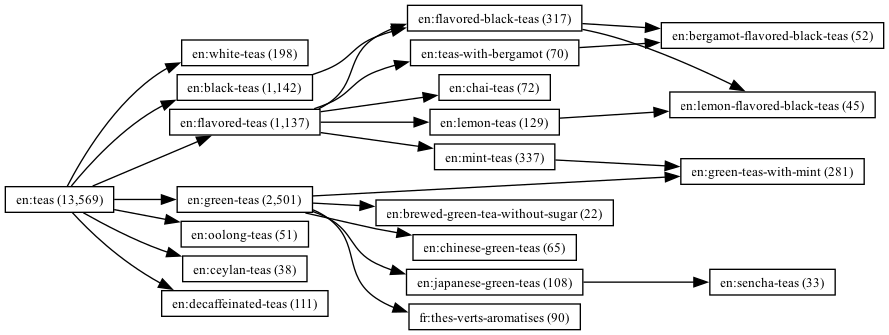

In [21]:
plot_graph(categories['en:teas'])

## Analyze Root Categories

In [22]:
show_children('en:plant-based-foods-and-beverages')

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:plant-based-foods,1,Plant-based foods,393287,Plant-based foods,Pflanzliche Lebensmittel,en:plant-based-foods-and-beverages,1,52
en:plant-based-beverages,1,Plant-based beverages,61329,Plant-based beverages,Pflanzliche Getränke,en:beverages|en:plant-based-foods-and-beverages,2,14
en:dairy-substitutes,1,Dairy substitutes,13856,Dairy substitutes,None,en:plant-based-foods-and-beverages,1,8
en:vegetable-based-foods-and-beverages,1,Vegetable-based foods and beverages,1419,Vegetable-based foods and beverages,Gemüse basierte Lebensmittel und Getränke,en:plant-based-foods-and-beverages,1,1


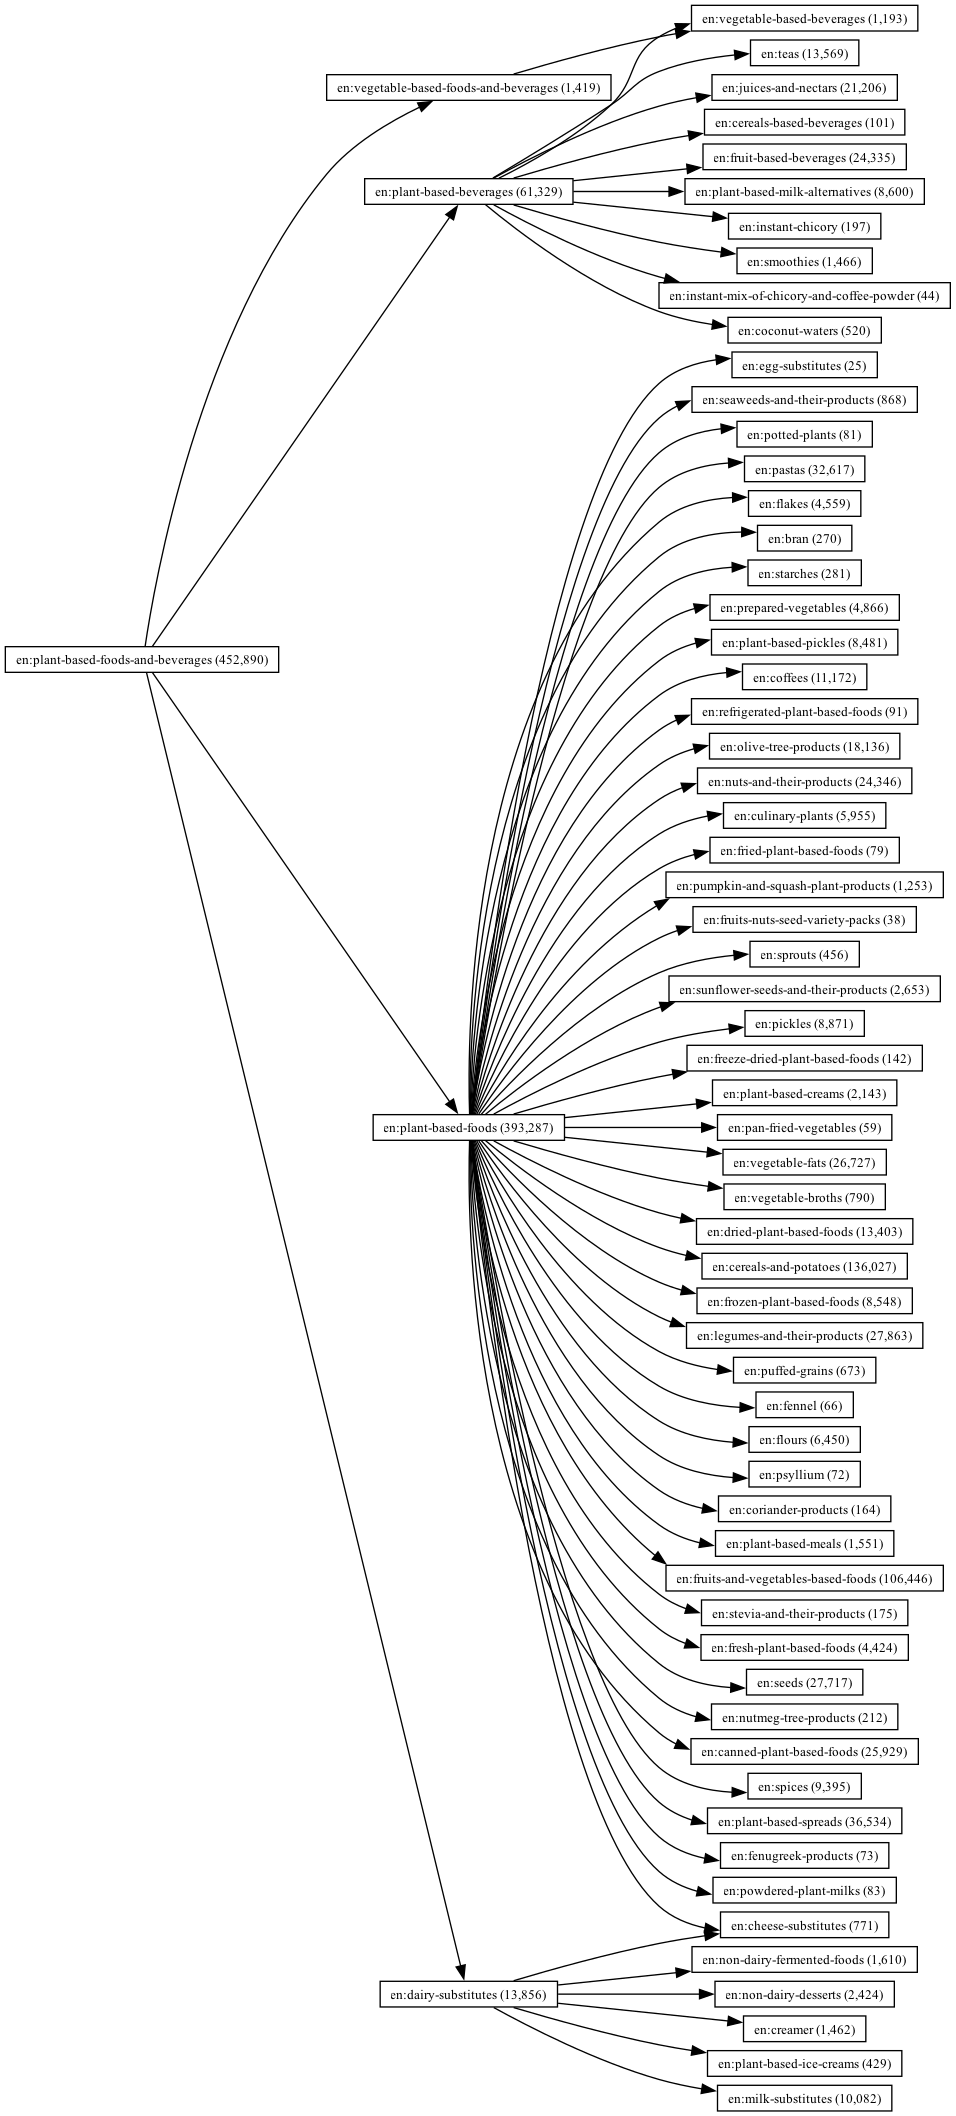

In [23]:
plot_graph(categories['en:plant-based-foods-and-beverages'], max_depth=2)

### Plant-based Beverages

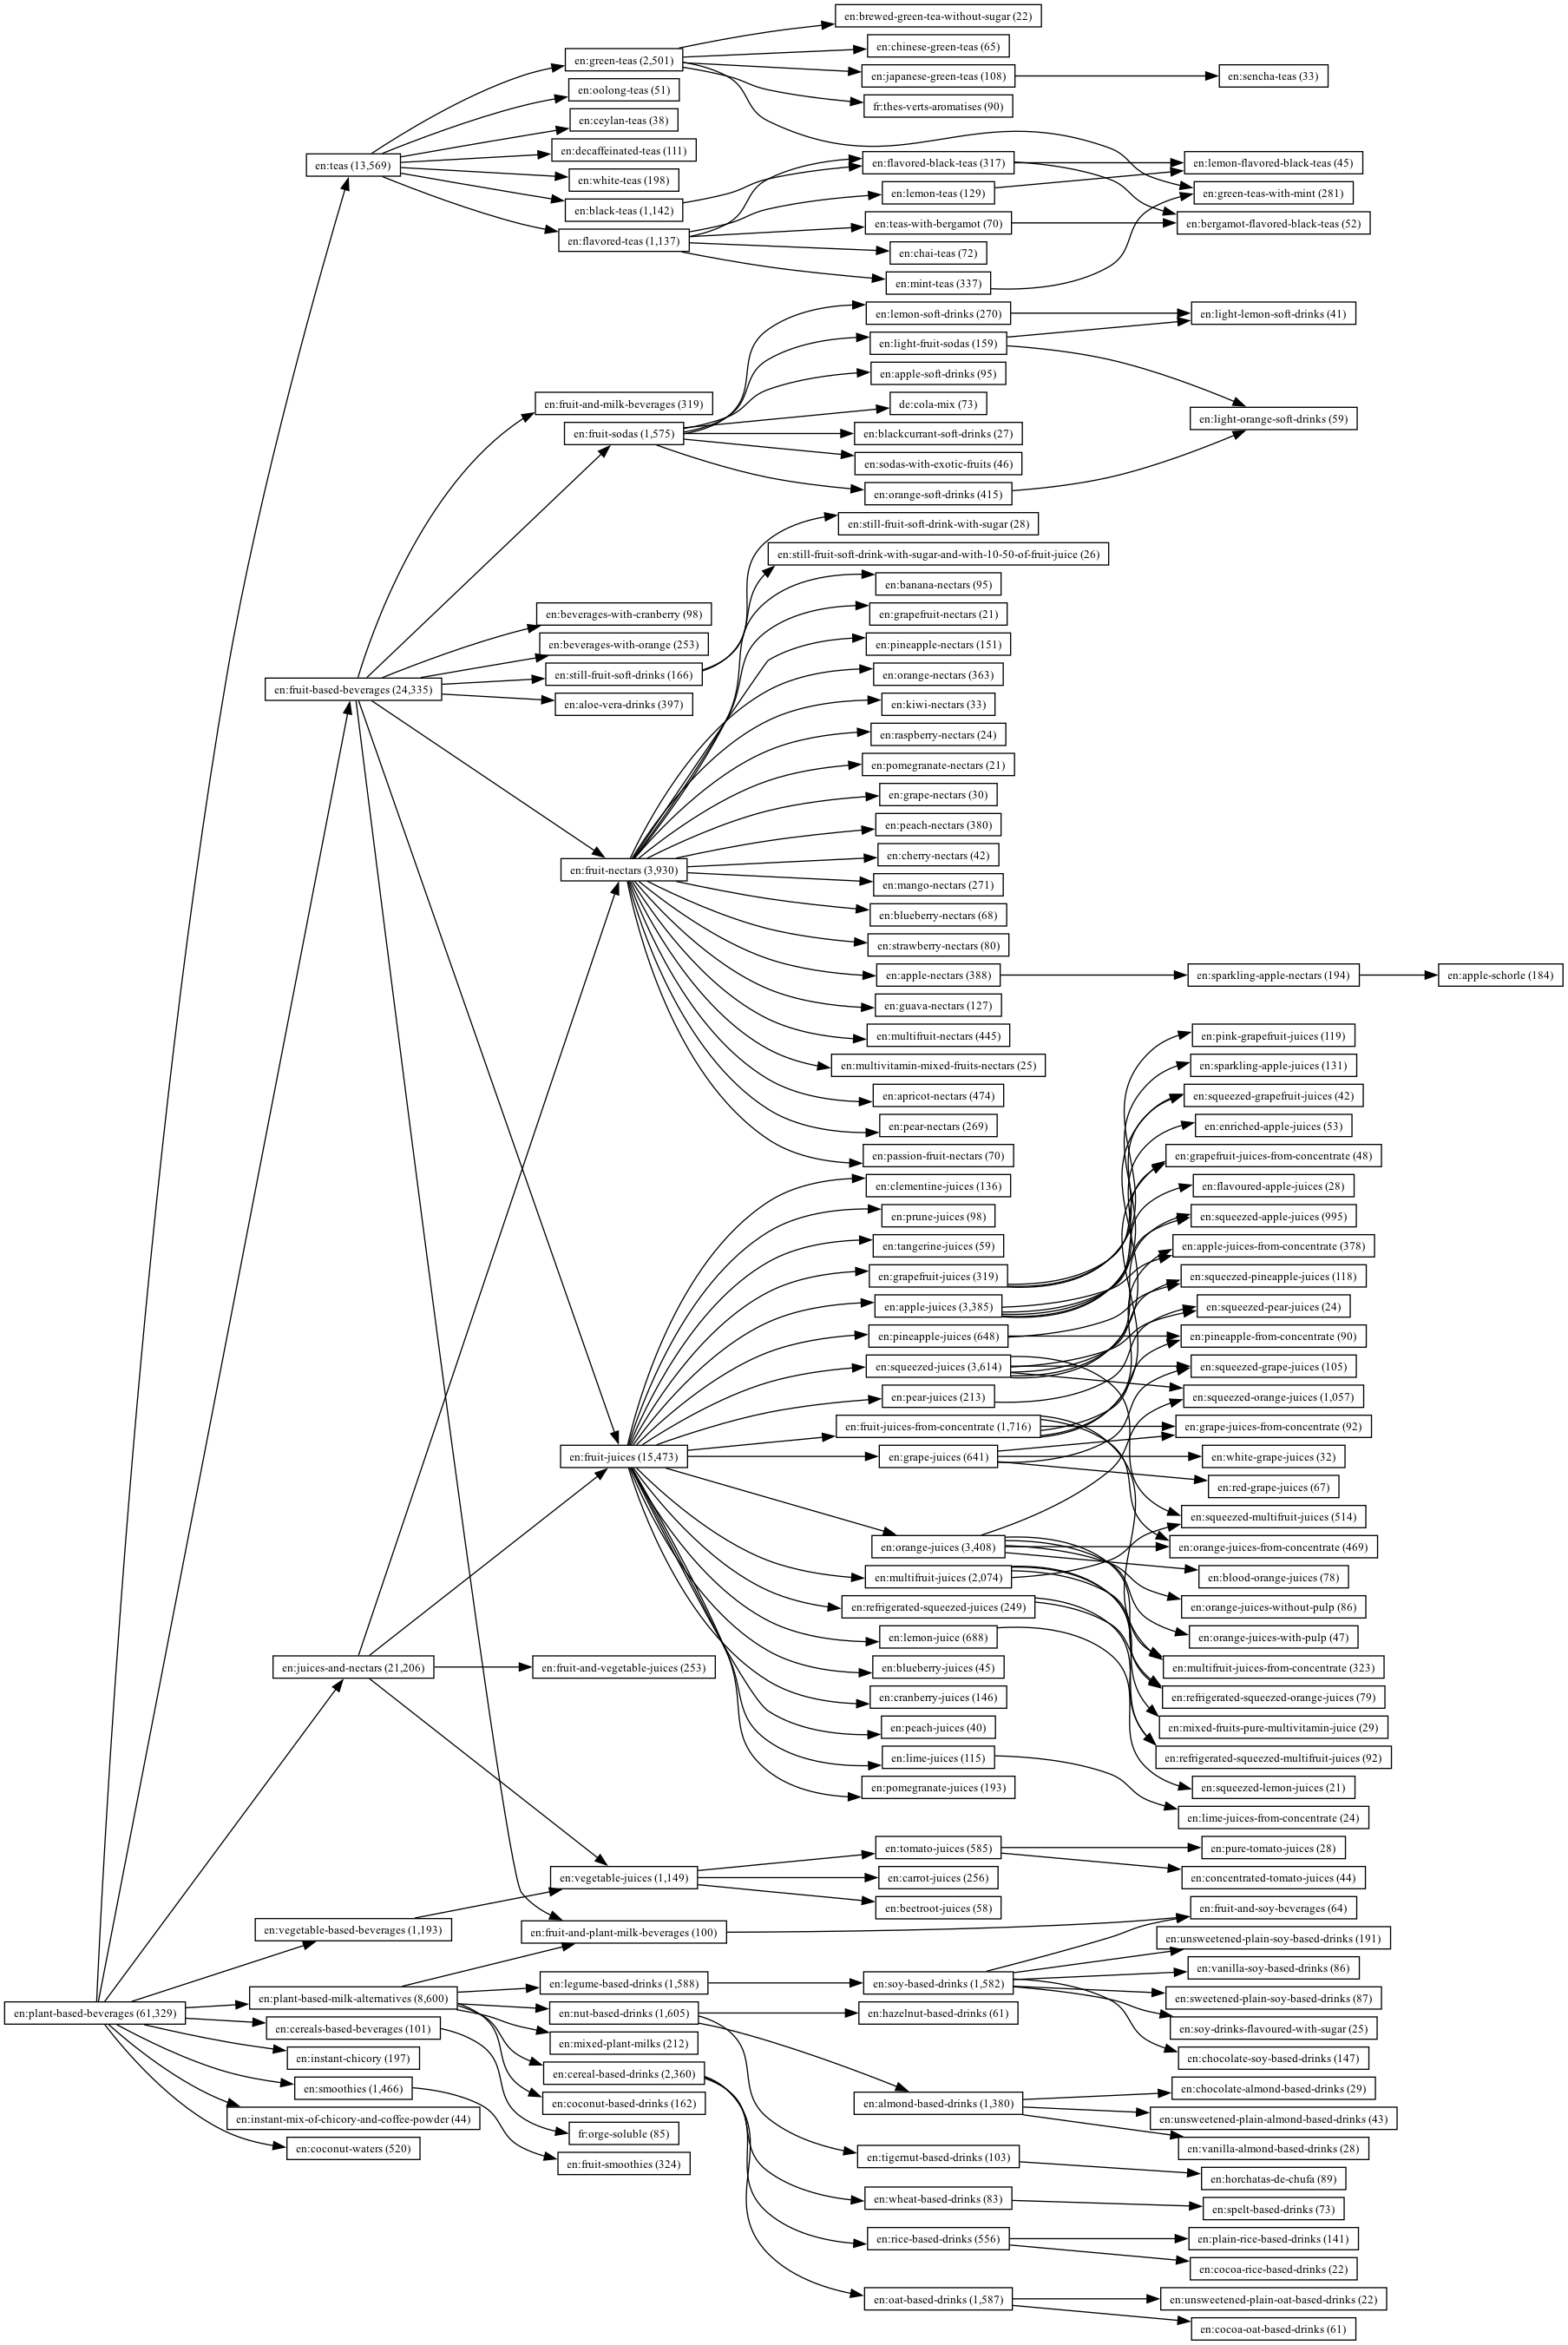

In [24]:
plot_graph(categories['en:plant-based-beverages'])

In [25]:
show_children('en:plant-based-beverages')

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:fruit-based-beverages,1,Fruit-based beverages,24335,Fruit-based beverages,Fruchtgetränke,en:plant-based-beverages,1,10
en:juices-and-nectars,1,Juices and nectars,21206,Juices and nectars,Säfte und Nektare,en:plant-based-beverages,1,4
en:teas,1,Teas,13569,Teas,Tees,en:hot-beverages|en:plant-based-beverages,2,11
en:plant-based-milk-alternatives,1,Plant-based milk alternatives,8600,Plant-based milk alternatives,Pflanzenmilch,en:milk-substitutes|en:plant-based-beverages,2,7
en:smoothies,1,Smoothies,1466,Smoothies,Smoothies,en:plant-based-beverages,1,2
en:vegetable-based-beverages,1,Vegetable-based beverages,1193,Vegetable-based beverages,Gemüse basierte Getränke,en:plant-based-beverages|en:vegetable-based-fo...,2,1
en:coconut-waters,1,Coconut waters,520,Coconut waters,Kokoswasser,en:plant-based-beverages,1,0
en:instant-chicory,1,Instant chicory,197,Instant chicory,None,en:instant-coffee-substitutes|en:plant-based-b...,2,1
en:cereals-based-beverages,1,Cereals-based beverages,101,Cereals-based beverages,None,en:instant-beverages|en:plant-based-beverages,2,1


### Juices and Nectars

- ignore
  - refrigerated
  - from-concentrate (not healthy)
  - en:fruit-juice-mixed-apple-base-standard
- keep squeezed (Direktsaft)

In [26]:
show_children('en:fruit-juices')

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:squeezed-juices,1,Squeezed juices,3614,Squeezed juices,Direktsäfte,en:fruit-juices,1,11
en:orange-juices,1,Orange juices,3408,Orange juices,Orangensäfte,en:fruit-juices,1,7
en:apple-juices,1,Apple juices,3385,Apple juices,Apfelsaft,en:fruit-juices|en:unsweetened-beverages,2,6
en:multifruit-juices,1,Multifruit juices,2074,Multifruit juices,Multifruchtsäfte,en:fruit-juices,1,6
en:fruit-juices-from-concentrate,1,Fruit juices from concentrate,1716,Fruit juices from concentrate,Fruchtsäfte aus Konzentrat,en:fruit-juices,1,13
en:lemon-juice,1,Lemon juice,688,Lemon juice,Zitronensäfte,en:fruit-juices,1,2
en:pineapple-juices,1,Pineapple juices,648,Pineapple juices,Ananassäfte,en:fruit-juices,1,3
en:grape-juices,1,Grape juices,641,Grape juices,Traubensäfte,en:fruit-juices,1,4
en:grapefruit-juices,1,Grapefruit juices,319,Grapefruit juices,Grapefruitsäfte,en:fruit-juices,1,5


In [27]:
show_children('en:squeezed-juices')

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:squeezed-orange-juices,1,Squeezed orange juices,1057,Squeezed orange juices,Orangendirektsäfte,en:orange-juices|en:squeezed-juices,2,0
en:squeezed-apple-juices,1,Squeezed apple juices,995,Squeezed apple juices,Apfeldirektsäfte,en:apple-juices|en:squeezed-juices,2,0
en:squeezed-multifruit-juices,1,Squeezed multifruit juices,514,Squeezed multifruit juices,Multifruchtdirektsäfte,en:multifruit-juices|en:squeezed-juices,2,0
en:squeezed-pineapple-juices,1,Squeezed pineapple juices,118,Squeezed pineapple juices,Ananasdirektsäfte,en:pineapple-juices|en:squeezed-juices,2,0
en:squeezed-grape-juices,1,Squeezed grape juices,105,Squeezed grape juices,Traubendirektsäfte,en:grape-juices|en:squeezed-juices,2,0
en:squeezed-grapefruit-juices,1,Squeezed grapefruit juices,42,Squeezed grapefruit juices,Grapefruitdirektsäfte,en:grapefruit-juices|en:squeezed-juices,2,0
en:squeezed-pear-juices,1,Squeezed pear juices,24,Squeezed pear juices,Birnendirektsäfte,en:pear-juices|en:squeezed-juices,2,0


In [28]:
show_children('en:fruit-juices-from-concentrate')

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:orange-juices-from-concentrate,1,Orange juices from concentrate,469,Orange juices from concentrate,Orangensäfte aus Konzentrat,en:fruit-juices-from-concentrate|en:orange-juices,2,0
en:apple-juices-from-concentrate,1,Apple juices from concentrate,378,Apple juices from concentrate,Apfelsäfte aus Konzentrat,en:apple-juices|en:fruit-juices-from-concentrate,2,0
en:multifruit-juices-from-concentrate,1,Multifruit juices from concentrate,323,Multifruit juices from concentrate,Multifruchtsäfte aus Konzentrat,en:fruit-juices-from-concentrate|en:multifruit...,2,0
en:grape-juices-from-concentrate,1,Grape juices from concentrate,92,Grape juices from concentrate,Traubensäfte aus Konzentrat,en:fruit-juices-from-concentrate|en:grape-juices,2,0
en:pineapple-from-concentrate,1,Pineapple from concentrate,90,Pineapple from concentrate,Ananassäfte aus Konzentrat,en:fruit-juices-from-concentrate|en:pineapple-...,2,0
en:grapefruit-juices-from-concentrate,1,Grapefruit juices from concentrate,48,Grapefruit juices from concentrate,Grapefruitsäfte aus Konzentrat,en:fruit-juices-from-concentrate|en:grapefruit...,2,0


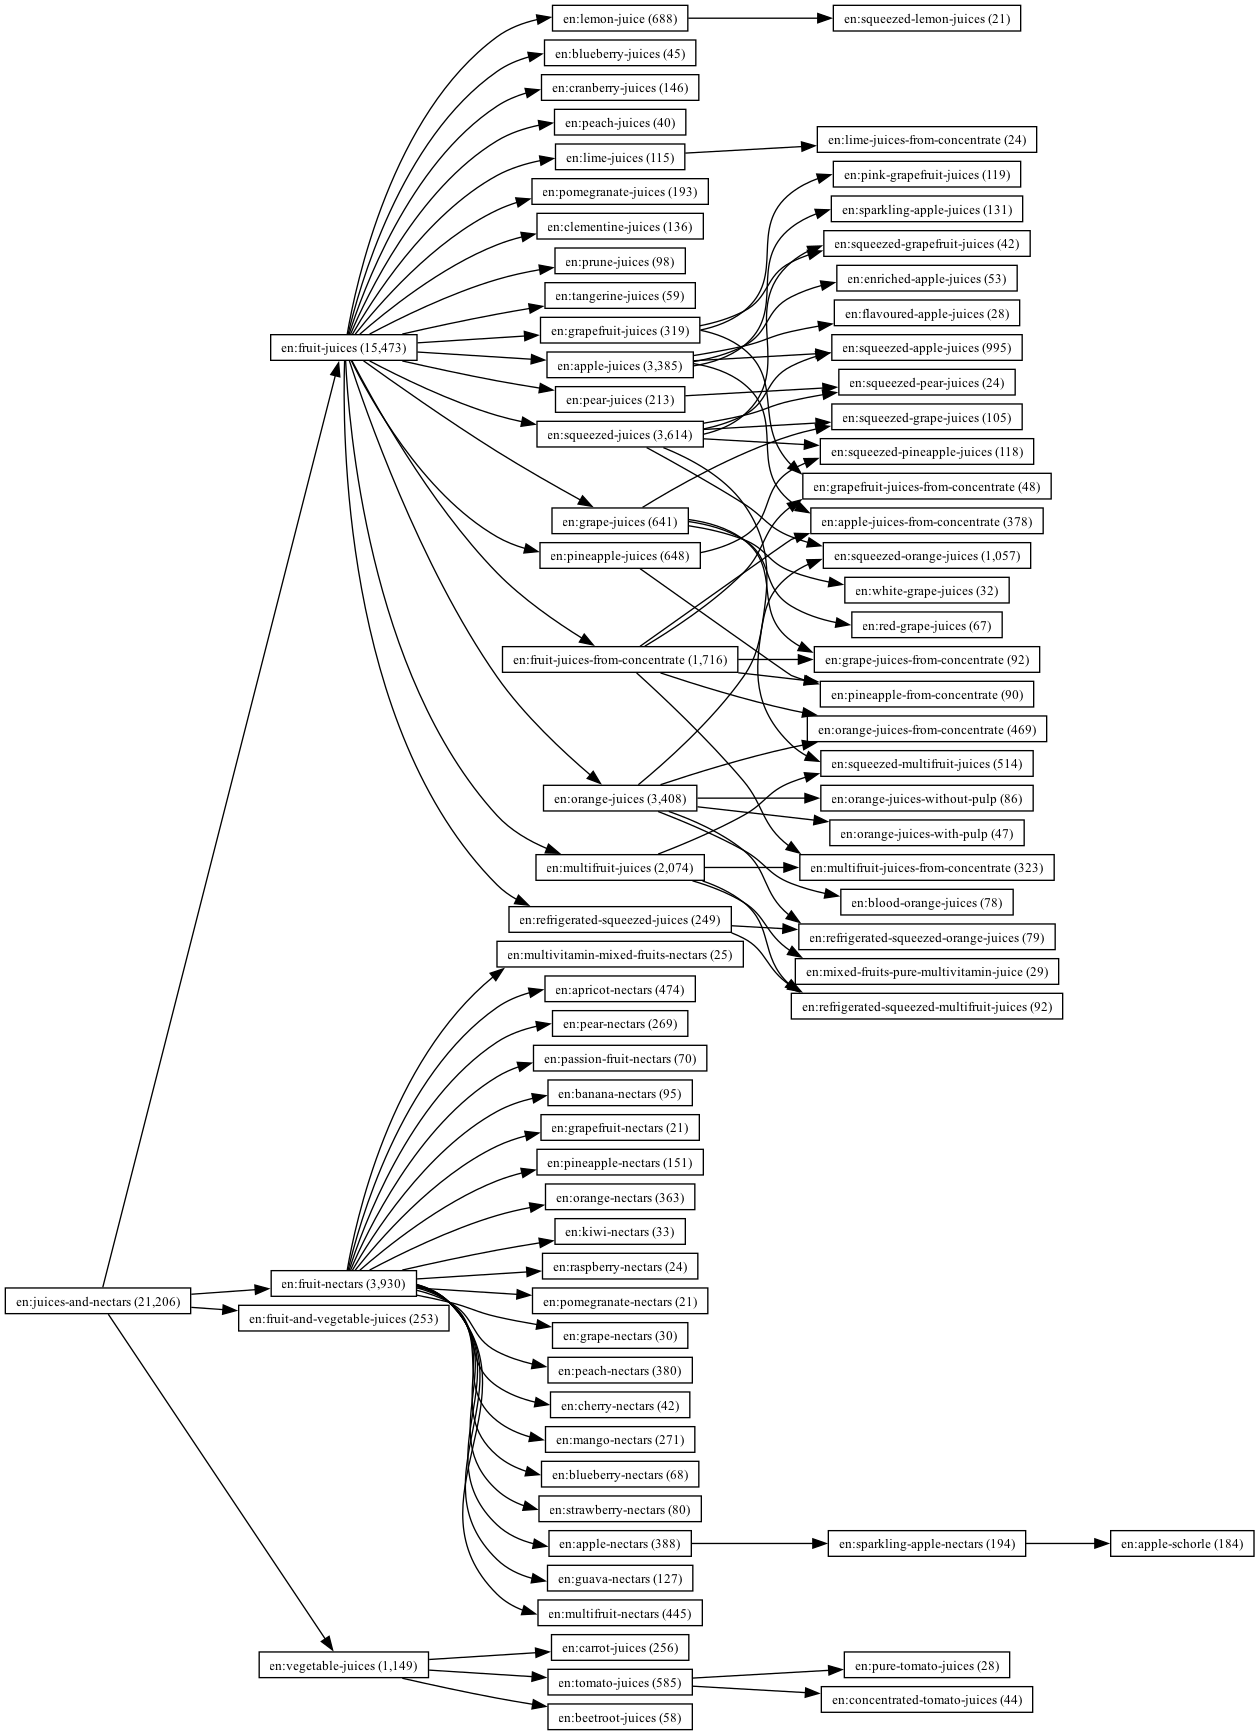

In [29]:
plot_graph(categories['en:juices-and-nectars'])

In [30]:
cat_df[cat_df.index.str.contains("chicory")].head(10)

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:instant-chicory,1,Instant chicory,197,Instant chicory,None,en:instant-coffee-substitutes|en:plant-based-b...,2,1
en:chicory,0,chicory,136,None,None,None,-1,-1
en:instant-mix-of-chicory-and-coffee-powder,1,Instant mix of chicory and coffee powder,44,Instant mix of chicory and coffee powder,None,en:instant-beverages|en:plant-based-beverages,2,0


In [31]:
show_children('en:fruit-based-beverages')

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:fruit-juices,1,Fruit juices,15473,Fruit juices,Fruchsäfte,en:fruit-based-beverages|en:juices-and-nectars,2,22
en:fruit-nectars,1,Fruit nectars,3930,Fruit nectars,Fruchtnektare,en:fruit-based-beverages|en:juices-and-nectars,2,24
en:fruit-sodas,1,Fruit sodas,1575,Fruit sodas,Fruchtlimonaden,en:fruit-based-beverages|en:sodas,2,7
en:aloe-vera-drinks,1,Aloe Vera drinks,397,Aloe Vera drinks,Aloe Vera Saften,en:fruit-based-beverages,1,0
en:fruit-and-milk-beverages,1,Fruit and milk beverages,319,Fruit and milk beverages,Frucht- und Milchsäfte,en:dairy-drinks|en:fruit-based-beverages,2,0
en:beverages-with-orange,1,Beverages with orange,253,Beverages with orange,Getränke mit Orange,en:fruit-based-beverages,1,0
en:still-fruit-soft-drinks,1,Still fruit soft drinks,166,Still fruit soft drinks,None,en:fruit-based-beverages,1,5
en:fruit-and-plant-milk-beverages,1,Fruit and plant-milk beverages,100,Fruit and plant-milk beverages,None,en:fruit-based-beverages|en:plant-based-milk-a...,2,2
en:beverages-with-cranberry,1,Beverages with cranberry,98,Beverages with cranberry,Cranberry Getränke,en:fruit-based-beverages,1,0


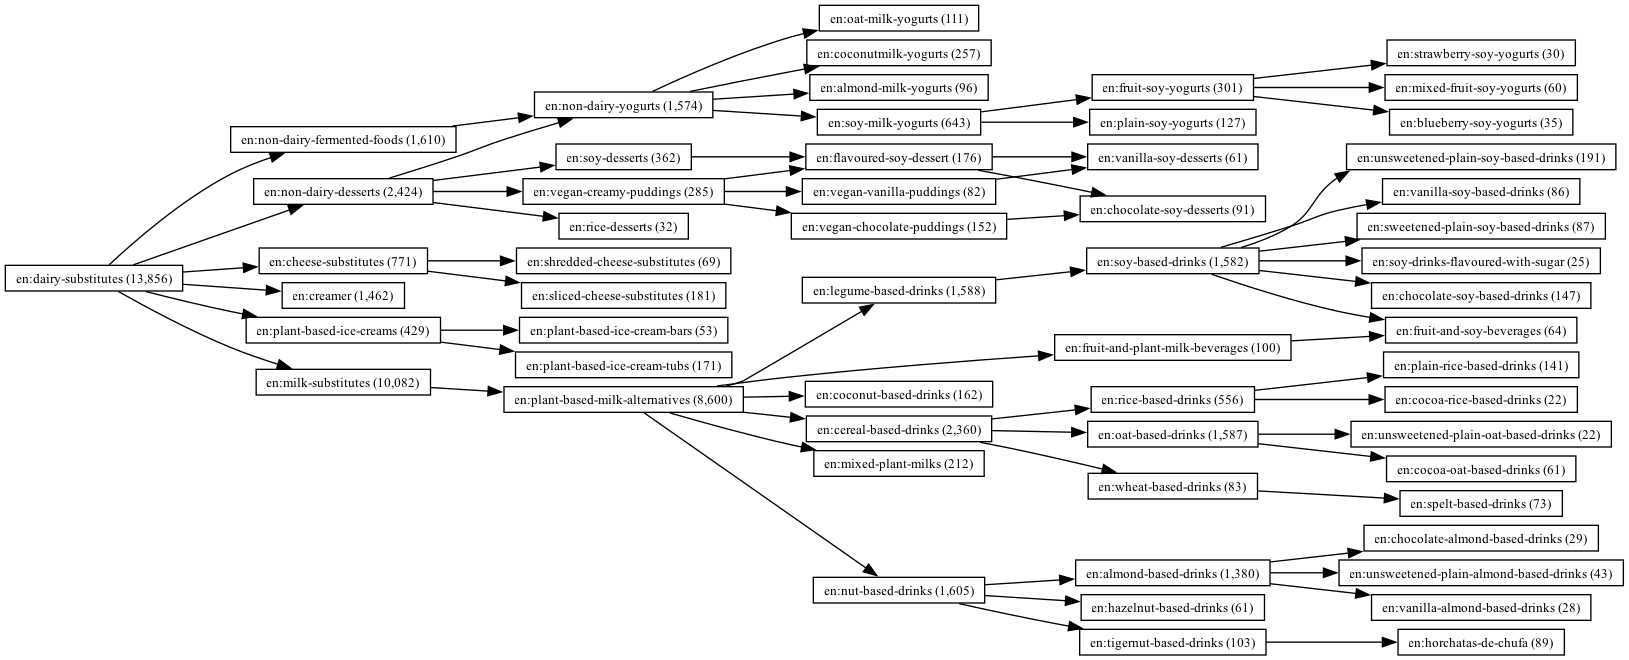

In [32]:
plot_graph(categories['en:dairy-substitutes'])

In [33]:
show_children('en:plant-based-foods')

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:cereals-and-potatoes,1,Cereals and potatoes,136027,Cereals and potatoes,Getreide und Kartoffeln,en:plant-based-foods,1,17
en:fruits-and-vegetables-based-foods,1,Fruits and vegetables based foods,106446,Fruits and vegetables based foods,Frucht- und gemüsebasierte Lebensmittel,en:plant-based-foods,1,4
en:plant-based-spreads,1,Plant-based spreads,36534,Plant-based spreads,Pflanzliche Brotaufstriche,en:plant-based-foods|en:spreads,2,26
en:pastas,1,Pastas,32617,Pastas,Teigwaren,en:plant-based-foods,1,94
en:legumes-and-their-products,1,Legumes and their products,27863,Legumes and their products,Hülsenfrüchte und Hülsenfruchtprodukte,en:plant-based-foods,1,16
en:seeds,1,Seeds,27717,Seeds,Samen,en:plant-based-foods,1,14
en:vegetable-fats,1,Vegetable fats,26727,Vegetable fats,Pflanzenfette,en:fats|en:plant-based-foods,2,7
en:canned-plant-based-foods,1,Canned plant-based foods,25929,Canned plant-based foods,Konserven-Produkte auf pflanzlicher Basis,en:canned-foods|en:plant-based-foods,2,10
en:nuts-and-their-products,1,Nuts and their products,24346,Nuts and their products,Nüsse und Nussprodukte,en:plant-based-foods,1,13


In [34]:
#categories["it:trenette"].children
#cat_df.loc["it:trenette"]#.products
#cat_df[~cat_df.index.duplicated()]

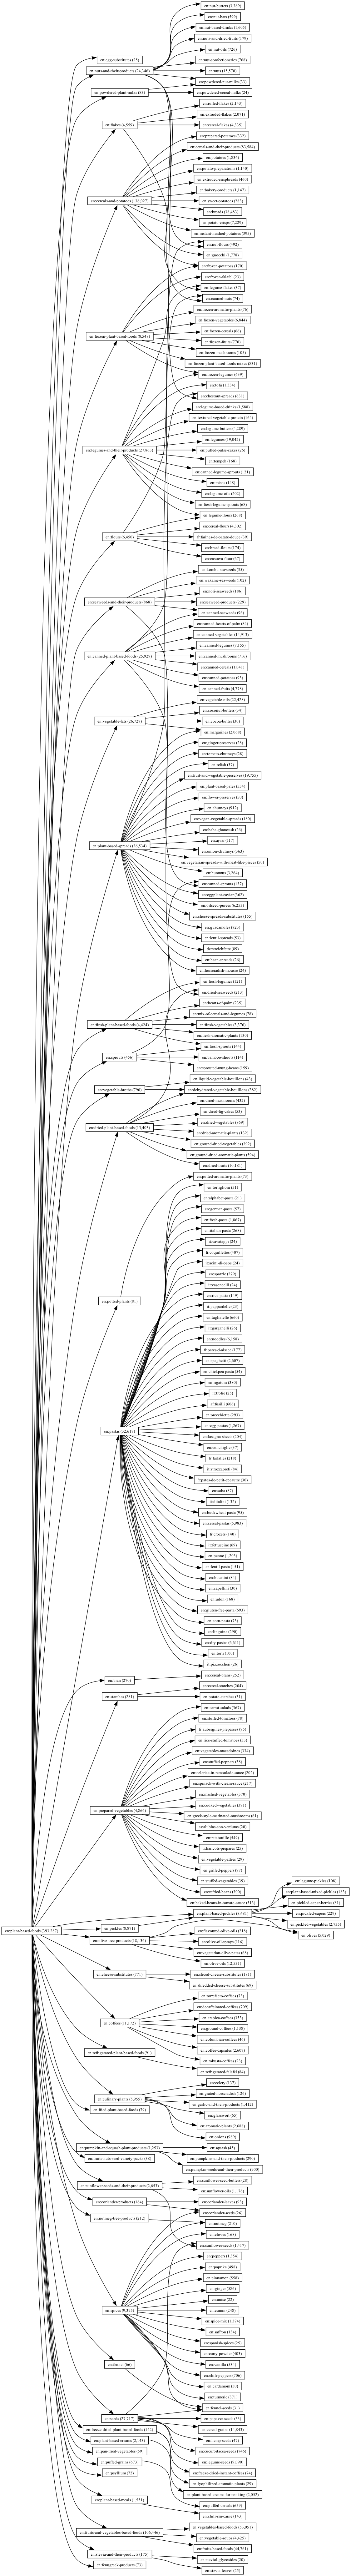

In [35]:
plot_graph(categories['en:plant-based-foods'], max_depth=2)

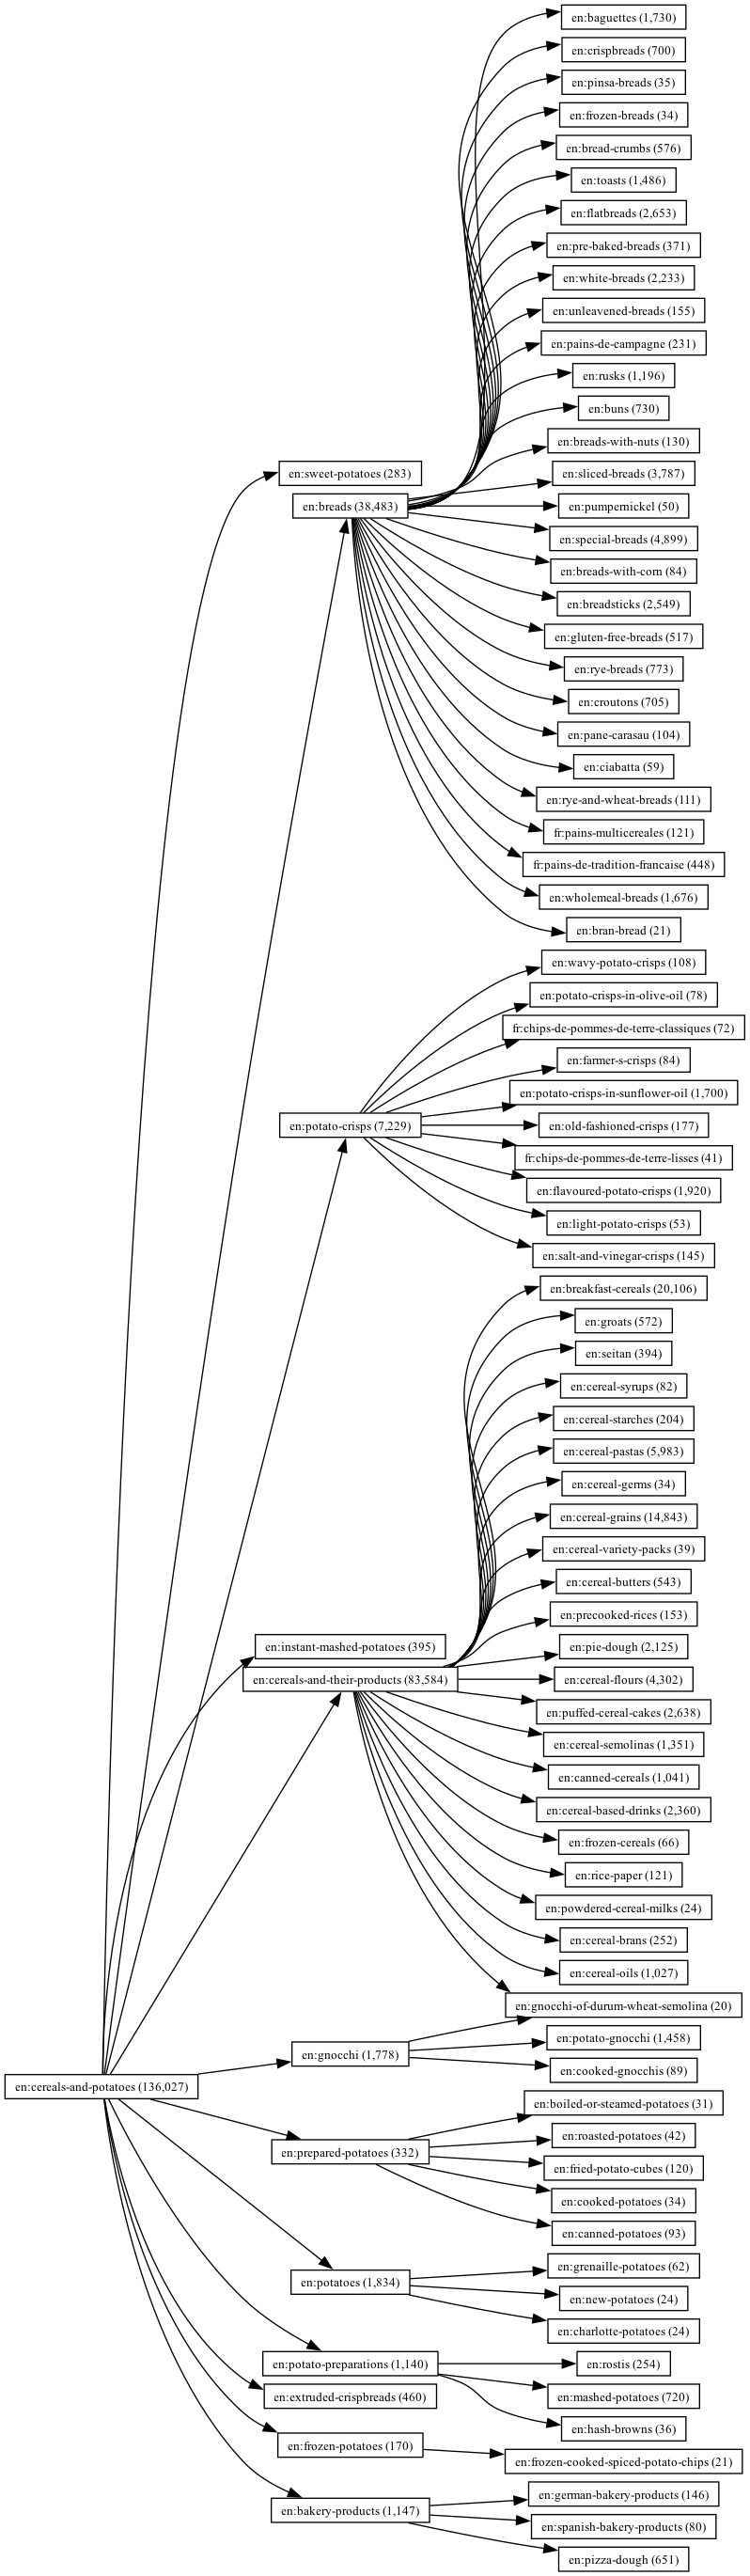

In [36]:
plot_graph(categories["en:cereals-and-potatoes"], max_depth=2)

### Any taxonomy entry contains name of parent

In [82]:
parents = cat_df.index.map(lambda x: '|'.join([cat.id[3:] for cat in categories[x].parents]) if categories[x] else None)
words = cat_df.index.map(lambda x: x[3:].split('-'))
df = pd.concat([pd.Series(words), pd.Series(parents)], axis=1)
#df.index = cat_df.index
df.columns = ['words', 'parents']

df['in_parent'] = df.apply(lambda row: [word for word in row.words if word in row.parents],axis = 1)
#df[df.in_parent.map(len) != 0]
df.in_parent.value_counts().head(50)

in_parent
[]               1085
[sauces]           60
[cheeses]          45
[yogurts]          40
[jams]             36
[beers]            32
[syrups]           32
[rices]            26
[honeys]           23
[wines]            21
[chocolates]       21
[pork]             20
[oils]             20
[cheese]           20
[milks]            20
[juices]           19
[nectars]          19
[sausages]         18
[spreads]          18
[sorbets]          18
[pasta]            18
[dried]            17
[breads]           16
[sandwiches]       16
[chicken]          16
[canned]           15
[pies]             15
[beef]             15
[crisps]           15
[soups]            15
[beverages]        14
[rillettes]        14
[terrines]         13
[frozen]           13
[chocolate]        13
[meat]             13
[teas]             13
[biscuits]         13
[vegetables]       13
[cakes]            13
[butters]          12
[meals]            11
[pizzas]           11
[salads]           10
[biscuit]          10


## Post-Processing

In [37]:
# only categories with taxnomomy entry
cat_df = cat_df[cat_df.name_en.notnull()]
cat_df

,known,name,products,name_en,name_de,parents,num_parents,num_children
id,,,,,,,,
en:plant-based-foods-and-beverages,1,Plant-based foods and beverages,452890,Plant-based foods and beverages,Pflanzliche Lebensmittel und Getränke,,0,4
en:plant-based-foods,1,Plant-based foods,393287,Plant-based foods,Pflanzliche Lebensmittel,en:plant-based-foods-and-beverages,1,52
en:snacks,1,Snacks,275343,Snacks,Imbiss,,0,5
en:sweet-snacks,1,Sweet snacks,202380,Sweet snacks,Süßer Snack,en:snacks,1,9
en:beverages,1,Beverages,174087,Beverages,Getränke,en:beverages-and-beverages-preparations,1,22
...,...,...,...,...,...,...,...,...
en:steviol-glycosides,1,Steviol glycosides,20,Steviol glycosides,None,en:natural-sugar-substitutes|en:stevia-and-the...,2,0
en:quail,1,Quail,20,Quail,None,en:poultries,1,2
en:saveloy-from-obernai-alsace,1,Saveloy from Obernai Alsace,20,Saveloy from Obernai Alsace,None,en:cervelat,1,0


## Save Categories

In [43]:
cat_df.name_en.rename('name').reset_index().to_json("./tax_en.json", orient='records')

In [39]:
cat_df.to_csv("./off_category_freq.csv")